# Exploratory Data Analysis (EDA)

Purpose: Analyze the raw brain MRI dataset to understand image properties, class distribution, and pixel intensity characteristics before preprocessing.

---

## 1. Setup and Imports

Import necessary libraries for data exploration and visualization.

In [7]:
# File operations and numerical computing
import os
import numpy as np
import pandas as pd

# Image processing
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style for better-looking plots
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")

All libraries imported successfully.


---

## 2. Dataset Overview

Load and count images from both classes:
- No tumor (negative class)
- Tumor present (positive class)

In [8]:
# Define paths to the raw dataset
no_path = "dataset/no"      # Images without brain tumor
yes_path = "dataset/yes"    # Images with brain tumor

# List all image files in each directory
no_images = sorted(os.listdir(no_path))
yes_images = sorted(os.listdir(yes_path))

# Display dataset size
print("=" * 50)
print("RAW DATASET SUMMARY")
print("=" * 50)
print(f"No tumor images:    {len(no_images):,}")
print(f"Tumor images:       {len(yes_images):,}")
print(f"Total images:       {len(no_images) + len(yes_images):,}")
print("=" * 50)

# Check class balance
balance_ratio = len(yes_images) / len(no_images)
print(f"\nClass Balance Ratio (yes/no): {balance_ratio:.2f}")
if 0.9 <= balance_ratio <= 1.1:
    print("Dataset is well-balanced.")
else:
    print("Dataset has class imbalance - consider weighted loss or resampling.")

RAW DATASET SUMMARY
No tumor images:    1,500
Tumor images:       1,500
Total images:       3,000

Class Balance Ratio (yes/no): 1.00
Dataset is well-balanced.


---

## 3. Visual Inspection of Random Samples

Visualize random samples from each class to understand image characteristics and quality.

Displaying random samples from each class:



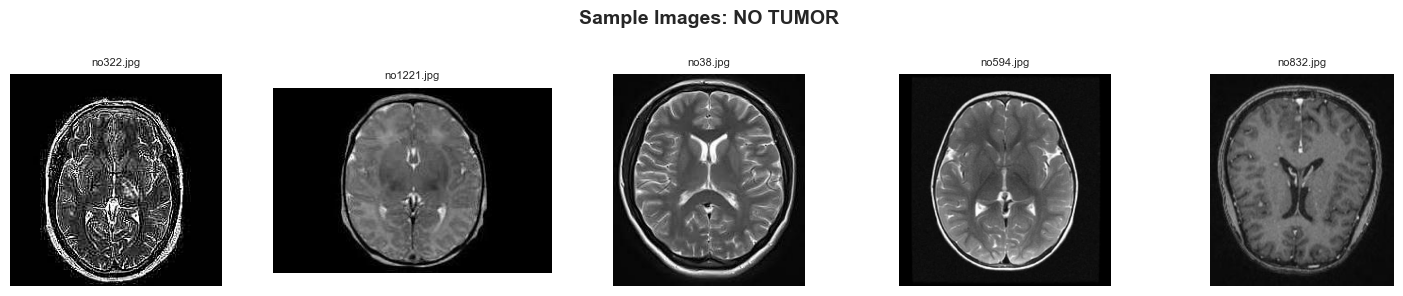

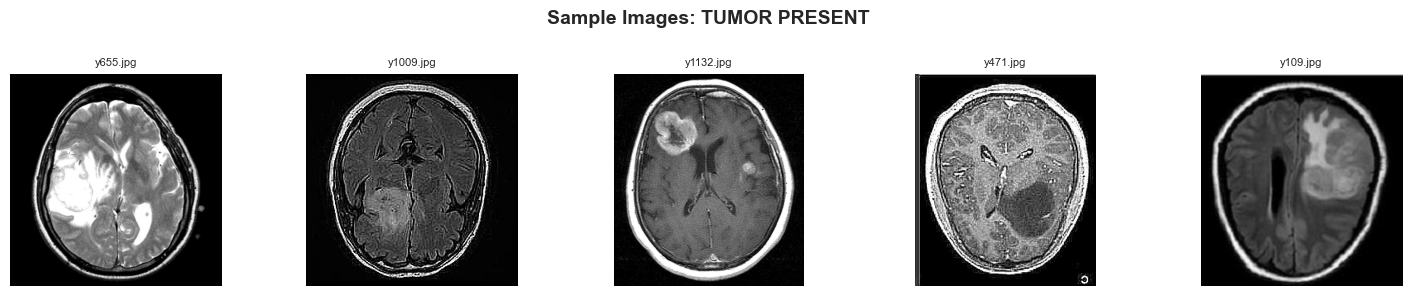

In [9]:
def show_random_samples(folder, class_name, n=5):
    """
    Display n random images from a given folder.
    
    Args:
        folder (str): Path to the image folder
        class_name (str): Name of the class for the title
        n (int): Number of samples to display
    """
    plt.figure(figsize=(15, 3))
    
    # Randomly select n images
    files = np.random.choice(os.listdir(folder), n, replace=False)
    
    for i, file in enumerate(files):
        img = Image.open(os.path.join(folder, file))
        
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(file, fontsize=8)
    
    plt.suptitle(f'Sample Images: {class_name.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display random samples from each class
print("Displaying random samples from each class:\n")
show_random_samples(no_path, "No Tumor")
show_random_samples(yes_path, "Tumor Present")

---

## 4. Image Dimension Analysis

Analyze image sizes to determine if resizing is necessary. Inconsistent dimensions require standardization for neural network input.

In [10]:
def get_image_shapes(folder):
    """
    Extract image dimensions (width, height) from all images in a folder.
    
    Args:
        folder (str): Path to the image folder
        
    Returns:
        list: List of tuples containing (width, height) for each image
    """
    shapes = []
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        shapes.append(img.size)  # PIL returns (width, height)
    return shapes

# Get shapes for both classes
no_shapes = get_image_shapes(no_path)
yes_shapes = get_image_shapes(yes_path)

# Convert to numpy arrays for statistical analysis
no_shapes_arr = np.array(no_shapes)
yes_shapes_arr = np.array(yes_shapes)

print("=" * 50)
print("IMAGE DIMENSION ANALYSIS")
print("=" * 50)

# Analyze 'No tumor' class
print("\nNO TUMOR CLASS:")
unique_no = np.unique(no_shapes_arr, axis=0)
print(f"  Unique sizes: {len(unique_no)}")
for size in unique_no[:5]:  # Show first 5
    count = np.sum(np.all(no_shapes_arr == size, axis=1))
    print(f"  - {size[0]}x{size[1]} pixels: {count} images")
if len(unique_no) > 5:
    print(f"  ... and {len(unique_no) - 5} more unique sizes")

# Analyze 'Tumor' class
print("\nTUMOR PRESENT CLASS:")
unique_yes = np.unique(yes_shapes_arr, axis=0)
print(f"  Unique sizes: {len(unique_yes)}")
for size in unique_yes[:5]:  # Show first 5
    count = np.sum(np.all(yes_shapes_arr == size, axis=1))
    print(f"  - {size[0]}x{size[1]} pixels: {count} images")
if len(unique_yes) > 5:
    print(f"  ... and {len(unique_yes) - 5} more unique sizes")

print("\n" + "=" * 50)
print("INSIGHT: Multiple image sizes detected.")
print("Action: Preprocessing will resize all images to 224x224")
print("Reason: Standardization is required for CNN input")
print("=" * 50)

IMAGE DIMENSION ANALYSIS

NO TUMOR CLASS:
  Unique sizes: 118
  - 150x198 pixels: 44 images
  - 173x201 pixels: 36 images
  - 177x197 pixels: 9 images
  - 192x192 pixels: 31 images
  - 194x259 pixels: 15 images
  ... and 113 more unique sizes

TUMOR PRESENT CLASS:
  Unique sizes: 182
  - 175x167 pixels: 1 images
  - 178x249 pixels: 1 images
  - 180x218 pixels: 8 images
  - 189x173 pixels: 9 images
  - 194x260 pixels: 20 images
  ... and 177 more unique sizes

INSIGHT: Multiple image sizes detected.
Action: Preprocessing will resize all images to 224x224
Reason: Standardization is required for CNN input


---

## 5. Pixel Intensity Distribution Analysis

Examine pixel intensity distributions to understand image contrast and brightness characteristics. This helps determine if normalization is needed.

Analyzing pixel intensity distributions...



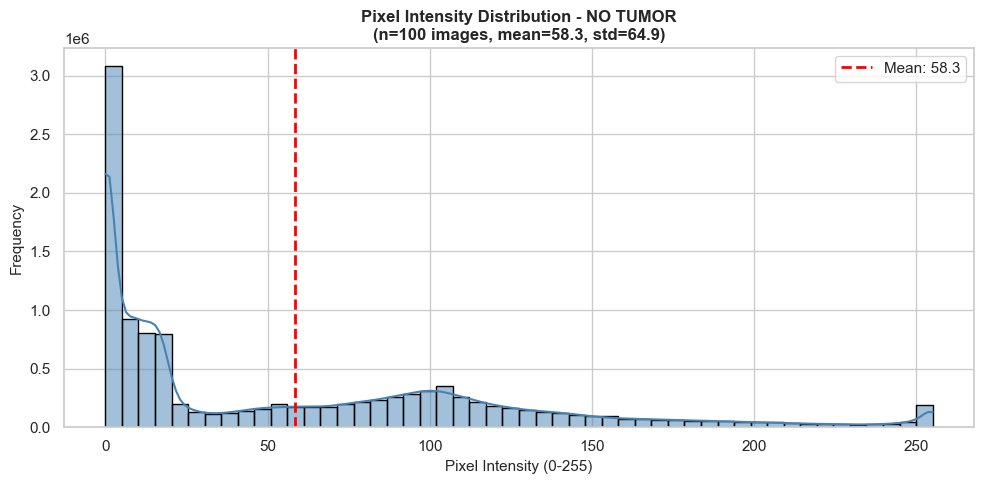

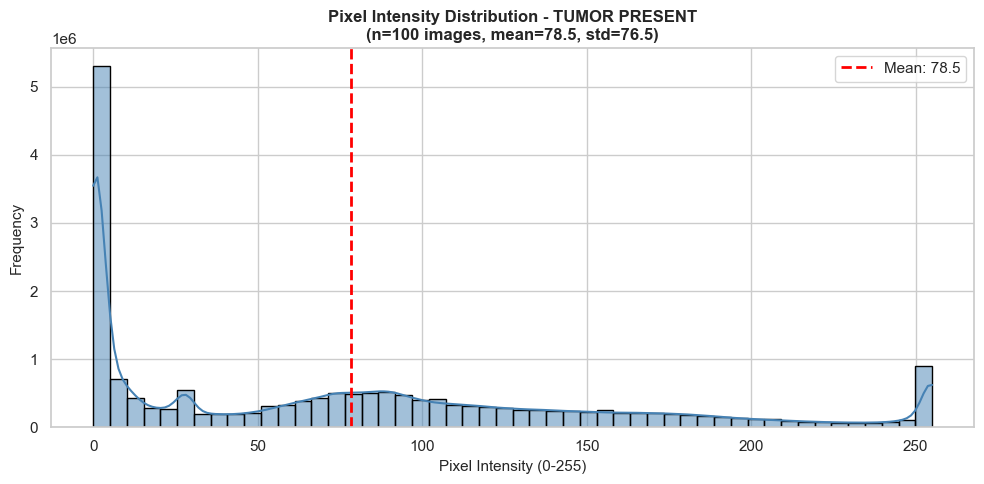


PIXEL INTENSITY COMPARISON
No Tumor:       Mean=58.34, Std=64.88
Tumor Present:  Mean=78.45, Std=76.53
Difference:     20.12 intensity units

Interpretation: Tumor images show different intensity patterns
This suggests hyperintense tumor regions in MRI scans.


In [11]:
def plot_pixel_distribution(folder, class_name, n=100):
    """
    Plot pixel intensity histogram for a random sample of images.
    
    Args:
        folder (str): Path to the image folder
        class_name (str): Name of the class for the title
        n (int): Number of images to sample for analysis
    """
    pixels = []
    
    # Sample n random images and extract all pixel values
    for file in np.random.choice(os.listdir(folder), n, replace=False):
        img = np.array(Image.open(os.path.join(folder, file)).convert('L'))  # Convert to grayscale
        pixels.extend(img.flatten())  # Flatten 2D image to 1D array
    
    # Create histogram with KDE overlay
    plt.figure(figsize=(10, 5))
    sns.histplot(pixels, bins=50, kde=True, color='steelblue', edgecolor='black')
    
    # Calculate statistics
    mean_intensity = np.mean(pixels)
    std_intensity = np.std(pixels)
    
    plt.title(f'Pixel Intensity Distribution - {class_name.upper()}\n(n={n} images, mean={mean_intensity:.1f}, std={std_intensity:.1f})', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Pixel Intensity (0-255)', fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.axvline(mean_intensity, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_intensity:.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return mean_intensity, std_intensity

# Analyze pixel distributions for both classes
print("Analyzing pixel intensity distributions...\n")
no_mean, no_std = plot_pixel_distribution(no_path, "No Tumor")
yes_mean, yes_std = plot_pixel_distribution(yes_path, "Tumor Present")

# Compare distributions
print("\n" + "=" * 50)
print("PIXEL INTENSITY COMPARISON")
print("=" * 50)
print(f"No Tumor:       Mean={no_mean:.2f}, Std={no_std:.2f}")
print(f"Tumor Present:  Mean={yes_mean:.2f}, Std={yes_std:.2f}")
print(f"Difference:     {abs(yes_mean - no_mean):.2f} intensity units")
print("=" * 50)

if abs(yes_mean - no_mean) > 10:
    print("\nInterpretation: Tumor images show different intensity patterns")
    print("This suggests hyperintense tumor regions in MRI scans.")
else:
    print("\nInterpretation: Similar intensity distributions between classes")

---

## 6. Class Balance Visualization

Visualize the distribution of samples across both classes to ensure balanced dataset.

CLASS DISTRIBUTION SUMMARY
        Class  Count  Percentage
     No Tumor   1500        50.0
Tumor Present   1500        50.0


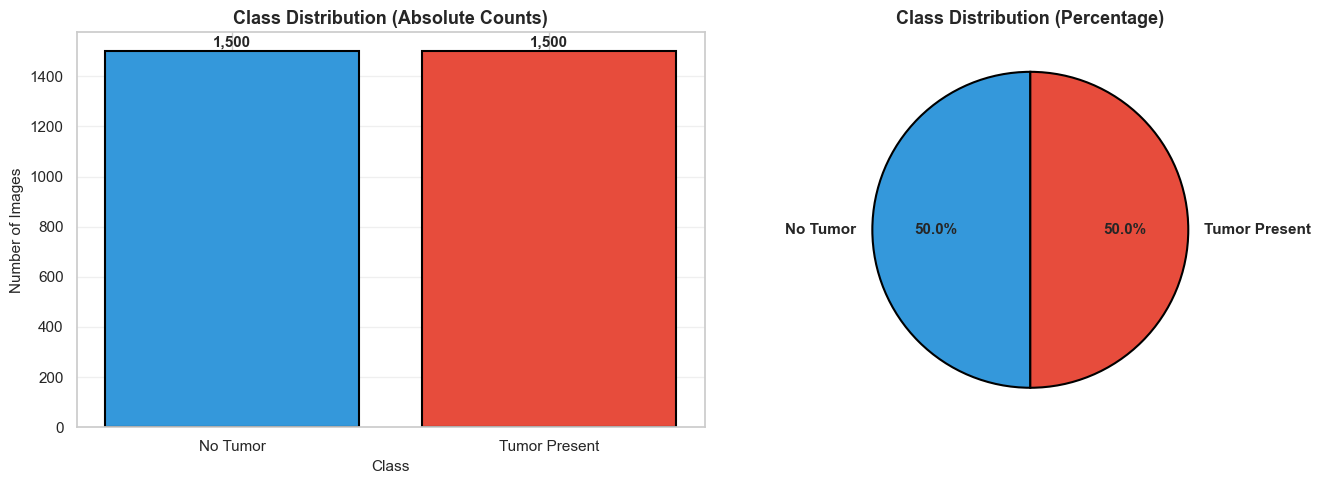


EDA Complete.
KEY FINDINGS:
  - Total images: 3,000
  - Classes are balanced
  - Variable image dimensions (requires resizing)
  - Distinct intensity patterns between classes

Next Step: Run 2preprocessing.ipynb to prepare data for training


In [12]:
# Create summary dataframe
data_summary = pd.DataFrame({
    'Class': ['No Tumor', 'Tumor Present'],
    'Count': [len(no_images), len(yes_images)],
    'Percentage': [len(no_images)/(len(no_images)+len(yes_images))*100,
                   len(yes_images)/(len(no_images)+len(yes_images))*100]
})

print("=" * 50)
print("CLASS DISTRIBUTION SUMMARY")
print("=" * 50)
print(data_summary.to_string(index=False))
print("=" * 50)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#3498db', '#e74c3c']
ax1.bar(data_summary['Class'], data_summary['Count'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Class Distribution (Absolute Counts)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=11)
ax1.set_xlabel('Class', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(data_summary.iterrows()):
    ax1.text(i, row['Count'] + 20, f"{row['Count']:,}", ha='center', fontweight='bold', fontsize=11)

# Pie chart
ax2.pie(data_summary['Count'], labels=data_summary['Class'], autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax2.set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEDA Complete.")
print("=" * 50)
print("KEY FINDINGS:")
print(f"  - Total images: {len(no_images) + len(yes_images):,}")
print(f"  - Classes are {'balanced' if 0.9 <= balance_ratio <= 1.1 else 'imbalanced'}")
print(f"  - Variable image dimensions (requires resizing)")
print(f"  - Distinct intensity patterns between classes")
print("=" * 50)
print("\nNext Step: Run 2preprocessing.ipynb to prepare data for training")